# 🔬 BioSLATE Phase 4 — Network & Pathway Analysis of Synthetic Lethal Targets

**Author:** Faith Ogundimu  
**Date:** August 2025 

__Notebook Purpose__  
To evaluate protein–protein interactions (PPIs) and biological pathway enrichment for potent synthetic lethal targets identified in Phase 3.  
This integrative analysis helps prioritise gene pairs that are functionally or physically connected, and assesses the broader biological relevance of hits.

__Inputs__  
- Potent SL hit pairs with HGNC symbols (from Phase 3)
- STRING v12.0 PPI data:  
  - `9606.protein.links.detailed.v12.0.txt`  
  - `9606.protein.info.v12.0.txt`
- HGNC symbol ↔ STRING protein ID mappings
- Optional: g:Profiler input gene sets

__Outputs__  
- Direct STRING PPI interactions (combined score ≥ 400) between SL gene pairs  
- CSV summary of which pairs have STRING-supported interactions  
- Pathway enrichment results (Reactome, KEGG, GO) via g:Profiler  
- CSV of enriched pathways for all SL genes or PPI-confirmed subset

__Analysis Summary__  
1. Check whether any biomarker–target pairs directly interact in STRING (high-confidence PPI).
2. Quantify interaction frequency to assess mechanistic plausibility of SL pairs.
3. Run g:Profiler to determine whether SL genes (or PPI-supported subset) are enriched in specific biological pathways.

### Step 1: Check Direct Interactions with STRING

In [4]:
import pandas as pd

# Load your data
hits = pd.read_csv('../results/CNA_quantitative_cluster_delta/potent_synthetic_lethal_hits_with_HGNC.csv')

# Load STRING interaction table
string = pd.read_csv('../database_files/STRING/9606.protein.links.detailed.v12.0.txt', sep=' ')
string['protein1'] = string['protein1'].str.replace('9606.', '', regex=False)
string['protein2'] = string['protein2'].str.replace('9606.', '', regex=False)

# Load STRING protein → gene symbol mapping
info = pd.read_csv('../database_files/STRING/9606.protein.info.v12.0.txt', sep='\t')
info['#string_protein_id'] = info['#string_protein_id'].str.replace('9606.', '', regex=False)

# Build gene ↔ protein ID dictionary
symbol_to_protein = dict(zip(info['preferred_name'], info['#string_protein_id']))

# Filter out hits without STRING mapping
hits = hits[
    hits['Biomarker_HGNC'].isin(symbol_to_protein) & 
    hits['TargetGene_HGNC'].isin(symbol_to_protein)
].copy()

# Map genes to STRING protein IDs
hits['protein1'] = hits['Biomarker_HGNC'].map(symbol_to_protein)
hits['protein2'] = hits['TargetGene_HGNC'].map(symbol_to_protein)

# Make both orderings to account for STRING's undirected edges
hits['pair1'] = hits['protein1'] + '_' + hits['protein2']
hits['pair2'] = hits['protein2'] + '_' + hits['protein1']

# Make STRING pair index
string['pair'] = string['protein1'] + '_' + string['protein2']

# Keep only high-confidence PPIs
string = string[string['combined_score'] >= 400]

# Check if pair exists in STRING
hits['PPI_found'] = hits['pair1'].isin(string['pair']) | hits['pair2'].isin(string['pair'])

# Done. You now have a column showing whether that biomarker-target pair interacts in STRING
hits[['Biomarker_HGNC', 'TargetGene_HGNC', 'PPI_found']].head()

# Save the PPI result table
hits[['Biomarker_HGNC', 'TargetGene_HGNC', 'PPI_found']].to_csv(
    '../results/CNA_quantitative_cluster_delta/potent_hits_STRING_PPI_check.csv', index=False
)

In [1]:
hits[['Biomarker_HGNC', 'TargetGene_HGNC', 'PPI_found']]

# Only 5/197 have direct interactions

NameError: name 'hits' is not defined

### Step 2: Check with g:Profiler

In [8]:
import pandas as pd

# Load your annotated hits file with PPI status
hits = pd.read_csv('../results/CNA_quantitative_cluster_delta/potent_hits_STRING_PPI_check.csv')

# Check All unique genes from potent hits
all_genes = pd.concat([
    hits['Biomarker_HGNC'],
    hits['TargetGene_HGNC']
]).dropna().astype(str).unique().tolist()

### Run Enrichment Analysis

In [6]:
import sys
import subprocess

# Install the gprofiler-official package if it's not already installed
subprocess.check_call([sys.executable, "-m", "pip", "install", "gprofiler-official"])

# Now import it using the correct module name for v1.0+
from gprofiler import GProfiler


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip3.10 install --upgrade pip


In [16]:
from gprofiler import GProfiler

# Initialise the client
gp = GProfiler(return_dataframe=True)

# Choose which gene set to analyse
gene_list = all_genes

# Run enrichment: REACTOME, GO, KEGG, etc., and include actual gene hits
results = gp.profile(
    organism='hsapiens',
    query=gene_list,
    sources=['GO:BP', 'REAC', 'KEGG'],
    no_evidences=False
)

# Preview top hits
results.head()

results.to_csv('../results/CNA_quantitative_cluster_delta/gprofiler_enrichment.csv', index=False)

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,intersections,evidences
0,KEGG,KEGG:05220,Chronic myeloid leukemia,4.605658e-07,True,Chronic myeloid leukemia,76,89,10,8484,0.112360,0.131579,query_1,[KEGG:00000],"[AKT2, MECOM, PIK3CB, PIK3CA, GAB2, E2F3, KRAS...","[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
1,KEGG,KEGG:04218,Cellular senescence,5.713665e-07,True,Cellular senescence,155,89,13,8484,0.146067,0.083871,query_1,[KEGG:00000],"[AKT2, PIK3CB, PIK3CA, CCNE1, LIN54, E2F3, KRA...","[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
2,GO:BP,GO:0010604,positive regulation of macromolecule metabolic...,8.704487e-06,True,"""Any process that increases the frequency, rat...",3288,157,54,21026,0.343949,0.016423,query_1,"[GO:0009893, GO:0043170, GO:0060255]","[EIF4G1, NCOA2, IGF2BP2, SUB1, CLNS1A, IL1RAP,...","[[IMP], [IDA, ISS, IBA, IEA], [IDA, IBA], [IEA..."
3,GO:BP,GO:0009893,positive regulation of metabolic process,9.833845e-06,True,"""Any process that activates or increases the f...",3597,157,57,21026,0.363057,0.015847,query_1,"[GO:0008152, GO:0019222, GO:0048522]","[EIF4G1, NCOA2, IGF2BP2, SUB1, CLNS1A, IL1RAP,...","[[IMP], [IDA, ISS, IBA, IEA], [IDA, IBA], [IEA..."
4,GO:BP,GO:0051301,cell division,3.725167e-05,True,"""The process resulting in division and partiti...",658,157,21,21026,0.133758,0.031915,query_1,[GO:0009987],"[SMC4, AHCTF1, ECT2, PIK3CB, WWTR1, ZC3HC1, EX...","[[IEA], [IMP, IEA], [IDA, IMP, IBA, IEA], [IEA..."


In [20]:
# Directly explode the 'intersections' column

mapping = results[['name', 'intersections']].explode('intersections')
mapping.columns = ['Pathway', 'Gene']

# Save to file
mapping.to_csv('../results/CNA_quantitative_cluster_delta/gene_to_pathway_map.csv', index=False)

### Step 3: Visualizations

#### 1. Barplot of Top Pathways (by −log₁₀(p-value))

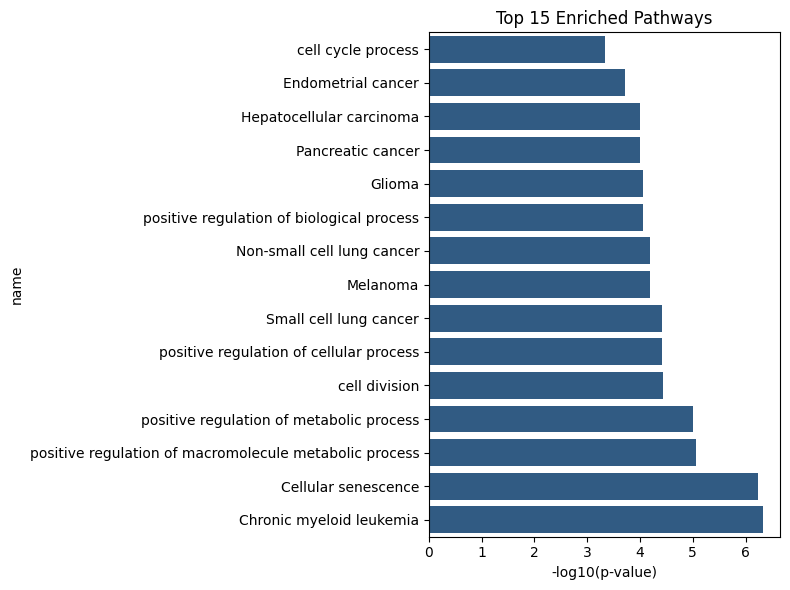

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load
df = pd.read_csv('../results/CNA_quantitative_cluster_delta/gprofiler_enrichment.csv')

# Filter significant
sig = df[df['significant'] == True].copy()

# Top 15 by p-value
top = df.nsmallest(15, 'p_value')

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(y='name', x=-np.log10(top['p_value']), data=top, color='#235b91')
plt.xlabel('-log10(p-value)')
plt.title('Top 15 Enriched Pathways')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Dot Plot (Pathway × Gene matrix as dots)

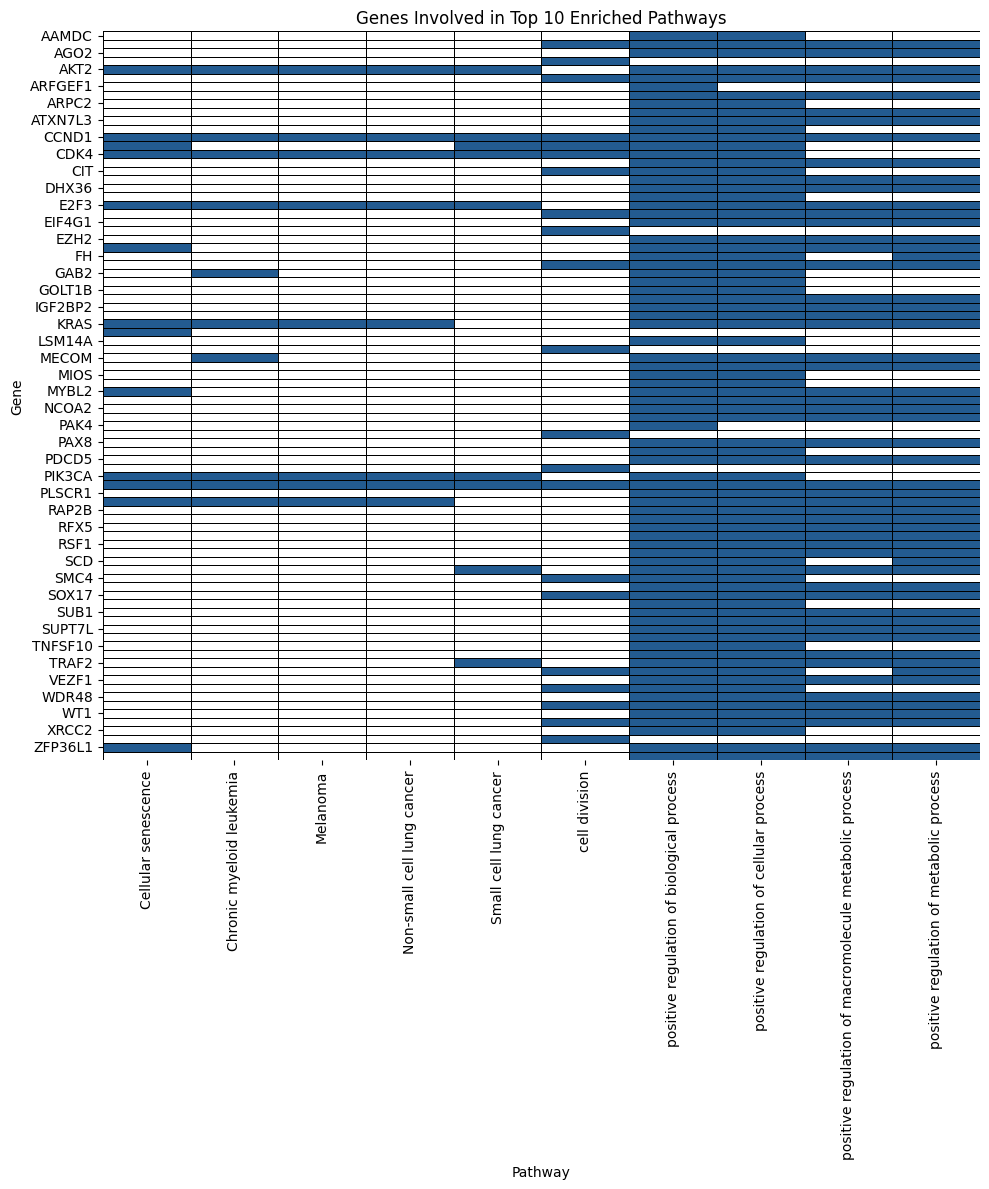

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Load gene-to-pathway mapping
mapping = pd.read_csv('../results/CNA_quantitative_cluster_delta/gene_to_pathway_map.csv')

# Filter to top 10 pathways by p-value
top_pathways = sig.nsmallest(10, 'p_value')['name'].tolist()
filtered = mapping[mapping['Pathway'].isin(top_pathways)]

# Create binary matrix (genes vs pathways)
dot_data = filtered.groupby(['Pathway', 'Gene']).size().unstack(fill_value=0)

# Custom colormap: white for 0, #235b91 for 1
cmap = ListedColormap(["white", "#235b91"])

# Plot
plt.figure(figsize=(10, 12))
sns.heatmap(
    dot_data.T, 
    cmap=cmap, 
    cbar=False, 
    linewidths=0.5, 
    linecolor="black"
)
plt.xlabel('Pathway')
plt.ylabel('Gene')
plt.title('Genes Involved in Top 10 Enriched Pathways')
plt.tight_layout()
plt.show()


#### Circular Pathway–Gene Network (Hive/Circos-style)

In [2]:
import sys
!{sys.executable} -m pip install holoviews bokeh 

  Using cached holoviews-1.21.0-py3-none-any.whl.metadata (10 kB)
  Using cached bokeh-3.7.3-py3-none-any.whl.metadata (12 kB)
  Using cached colorcet-3.1.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached panel-1.7.5-py3-none-any.whl.metadata (15 kB)
  Using cached param-2.2.1-py3-none-any.whl.metadata (6.6 kB)
  Using cached pyviz_comms-3.0.6-py3-none-any.whl.metadata (7.7 kB)
  Using cached xyzservices-2025.4.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached linkify_it_py-2.0.3-py3-none-any.whl.metadata (8.5 kB)
  Using cached mdit_py_plugins-0.4.2-py3-none-any.whl.metadata (2.8 kB)
  Using cached uc_micro_py-1.0.3-py3-none-any.whl.metadata (2.0 kB)
Using cached holoviews-1.21.0-py3-none-any.whl (5.9 MB)
Using cached bokeh-3.7.3-py3-none-any.whl (7.0 MB)
Using cached panel-1.7.5-py3-none-any.whl (29.5 MB)
Using cached param-2.2.1-py3-none-any.whl (119 kB)
Using cached pyviz_comms-3.0.6-py3-none-any.whl (84 kB)
Using cached xyzservices-2025.4.0-py3-none-any.whl (90 kB)
Using cache

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
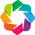

:Chord   [source,target]

In [19]:
import pandas as pd
import holoviews as hv
from holoviews import opts, dim
hv.extension('bokeh')

# Load gene-to-pathway mapping
mapping = pd.read_csv('../results/CNA_quantitative_cluster_delta/gene_to_pathway_map.csv')

# Step 1: Collapse redundant pathway terms
collapse_map = {
    # Cell cycle
    'cell cycle': 'Cell cycle',
    'cell cycle process': 'Cell cycle',
    'regulation of cell cycle': 'Cell cycle',
    'regulation of cell cycle process': 'Cell cycle',
    'regulation of cell cycle G1/S transition': 'Cell cycle',
    'G1/S transition of mitotic cell cycle': 'Cell cycle',
    'Mitotic G1 phase and G1/S transition': 'Cell cycle',
    'mitotic cell cycle': 'Cell cycle',
    'mitotic cell cycle process': 'Cell cycle',
    'Diseases of mitotic cell cycle': 'Cell cycle',
    'Aberrant regulation of mitotic cell cycle due to RB1 defects': 'Cell cycle',

    # Apoptosis
    'Apoptosis': 'Apoptosis',
    'apoptotic process': 'Apoptosis',
    'programmed cell death': 'Apoptosis',
    'cell death': 'Apoptosis',
    'regulation of apoptotic process': 'Apoptosis',

    # Signaling
    'PI3K-Akt signaling pathway': 'PI3K-Akt signaling',
    'mTOR signaling pathway': 'mTOR signaling',
    'FoxO signaling pathway': 'FoxO signaling',
    'VEGF signaling pathway': 'VEGF signaling',

    # Cancer umbrella
    'Pathways in cancer': 'Pathways in cancer',
    'Breast cancer': 'Breast cancer',
}

# Collapse into new column
mapping['CollapsedPathway'] = mapping['Pathway'].replace(collapse_map)

# Keep only collapsed pathway terms of interest
keep_terms = set(collapse_map.values())
subset = mapping[mapping['CollapsedPathway'].isin(keep_terms)]

# OPTIONAL: remove underpowered pathways (<3 genes)
counts = subset['CollapsedPathway'].value_counts()
valid_pathways = counts[counts >= 3].index
subset = subset[subset['CollapsedPathway'].isin(valid_pathways)]

# Build edges
edges = subset[['Gene', 'CollapsedPathway']].drop_duplicates()
edges.columns = ['Gene', 'Pathway']

# Build fixed node list
unique_pathways = edges['Pathway'].unique().tolist()
unique_genes = edges['Gene'].unique().tolist()
nodes_df = pd.DataFrame({'name': unique_pathways + unique_genes})
nodes_df['type'] = ['Pathway'] * len(unique_pathways) + ['Gene'] * len(unique_genes)
nodes_df['index'] = range(len(nodes_df))

# Define colours by pathway category
color_dict = {
    'Cell cycle': '#1f77b4',          # blue
    'Apoptosis': '#d62728',           # red
    'PI3K-Akt signaling': '#ff7f0e',  # orange
    'mTOR signaling': '#ffbb78',
    'FoxO signaling': '#2ca02c',
    'VEGF signaling': '#98df8a',
    'Pathways in cancer': '#7f7f7f',
    'Breast cancer': '#c7c7c7'
}

# Create Chord diagram with explicit node ordering
from holoviews.element.graphs import Chord

# Format edge table for Chord input
edges_named = edges.copy()
edges_named.columns = ['source', 'target']  # required names

# Create Chord with custom node list
chord = Chord((edges_named, hv.Dataset(nodes_df, 'name')))

chord.opts(
    opts.Chord(
        labels='name',
        node_color=dim('name').categorize(color_dict, default='#9edae5'),
        edge_color=dim('target').categorize(color_dict, default='#9edae5'),
        width=950,
        height=950,
        title="Gene–Pathway Interactions (Curated List)"
    )
)
